In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [6]:
# Configuration
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
warnings.filterwarnings('ignore')

In [7]:
# ==========================================
# 1. Data Loading & Preprocessing
# ==========================================
print("Loading data...")

# Load datasets
train = pd.read_csv('train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('store.csv')

# Merge train and store data
df = pd.merge(train, store, on='Store', how='left')

# Feature Extraction
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

# Clean StateHoliday
df['StateHoliday'] = df['StateHoliday'].astype(str).replace('0', 'Regular_Day')

# Filter: Keep only open stores with sales > 0 for analysis
df_open = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()

print(f"Data Loaded Successfully! Shape: {df.shape}")
print("-" * 30)

Loading data...
Data Loaded Successfully! Shape: (1001599, 23)
------------------------------


Plotting sales trends...


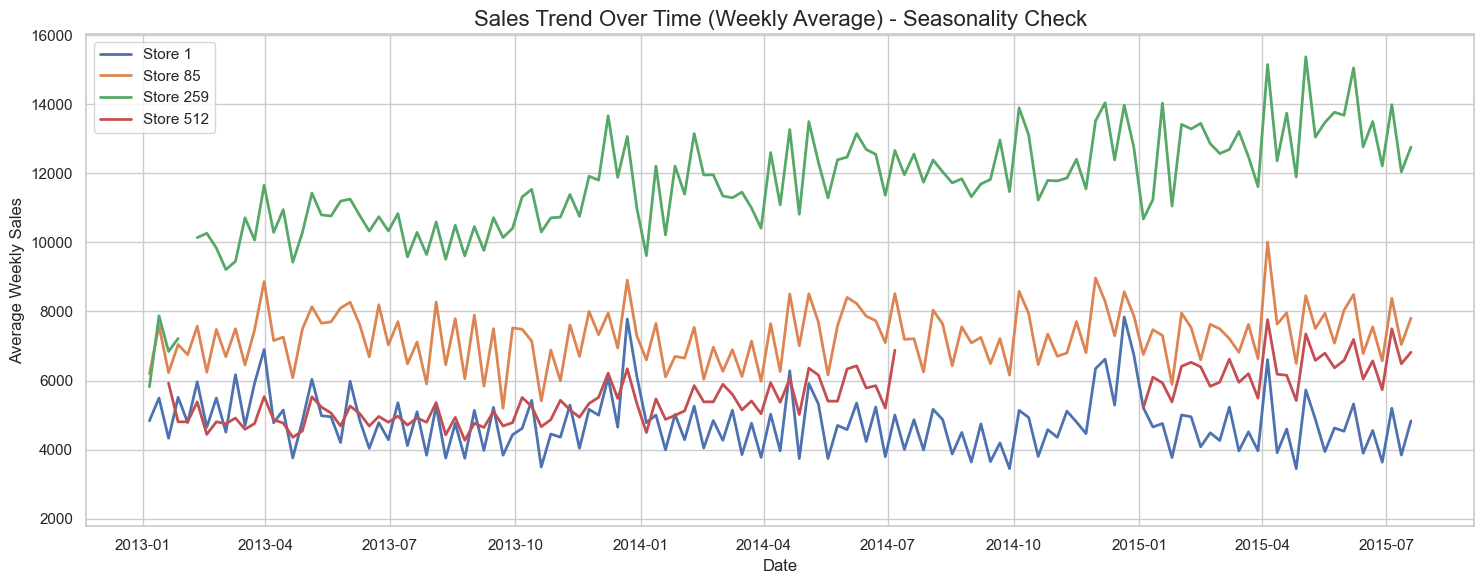

In [8]:
# ==========================================
# 2. Sales Trends Over Time
# ==========================================
print("Plotting sales trends...")

# Select 4 random stores for visualization
sample_stores = [1, 85, 259, 512] 

plt.figure(figsize=(15, 6))
for store_id in sample_stores:
    store_data = df_open[df_open['Store'] == store_id].sort_values('Date')
    # Resample weekly to smooth out daily noise
    store_weekly = store_data.set_index('Date')['Sales'].resample('W').mean()
    plt.plot(store_weekly.index, store_weekly, label=f'Store {store_id}', linewidth=2)

plt.title('Sales Trend Over Time (Weekly Average) - Seasonality Check', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Average Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

Analyzing feature impacts...


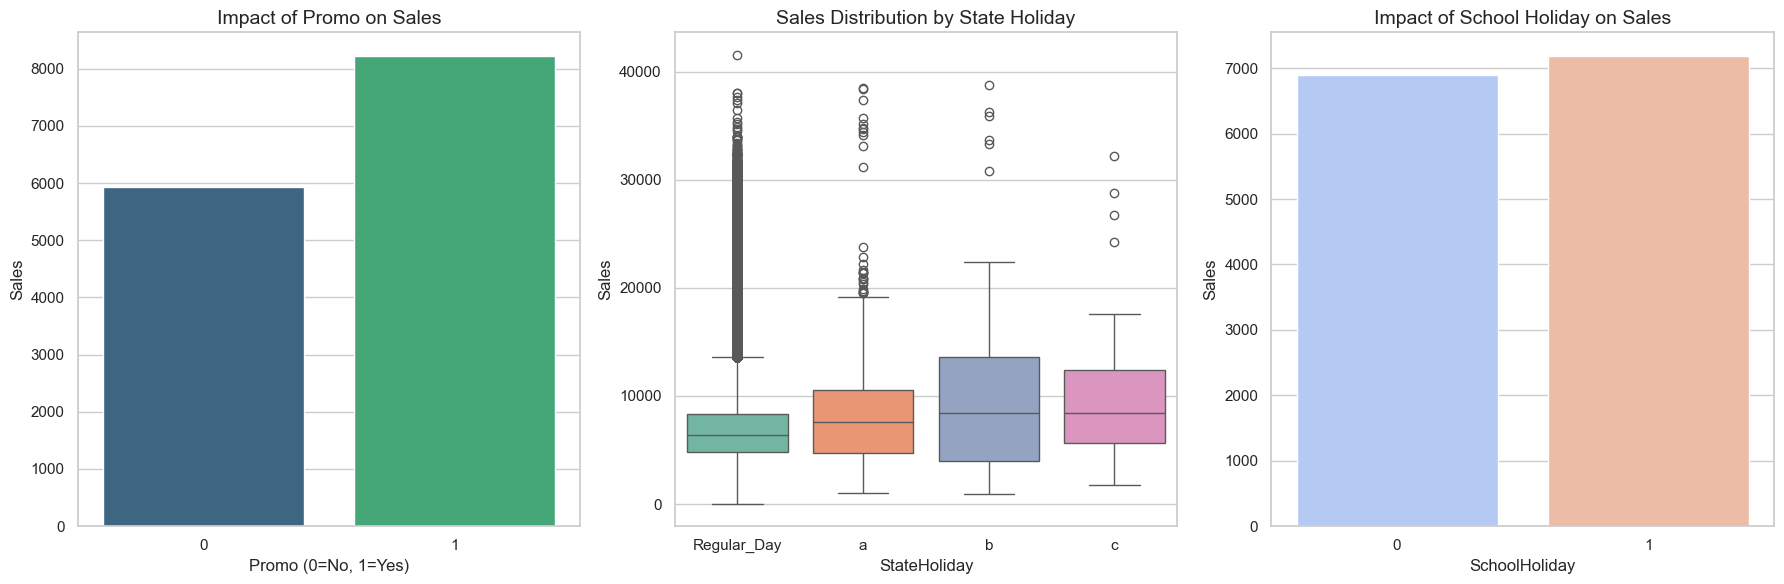

In [9]:
# ==========================================
# 3. Feature Impact Analysis
# ==========================================
print("Analyzing feature impacts...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A) Promo Impact
sns.barplot(x='Promo', y='Sales', data=df_open, ax=axes[0], palette='viridis', ci=None)
axes[0].set_title('Impact of Promo on Sales', fontsize=14)
axes[0].set_xlabel('Promo (0=No, 1=Yes)')

# B) StateHoliday Impact (a=Public, b=Easter, c=Christmas)
sns.boxplot(x='StateHoliday', y='Sales', data=df_open, ax=axes[1], palette='Set2')
axes[1].set_title('Sales Distribution by State Holiday', fontsize=14)

# C) SchoolHoliday Impact
sns.barplot(x='SchoolHoliday', y='Sales', data=df_open, ax=axes[2], palette='coolwarm', ci=None)
axes[2].set_title('Impact of School Holiday on Sales', fontsize=14)

plt.tight_layout()
plt.show()


Generating correlation matrix...


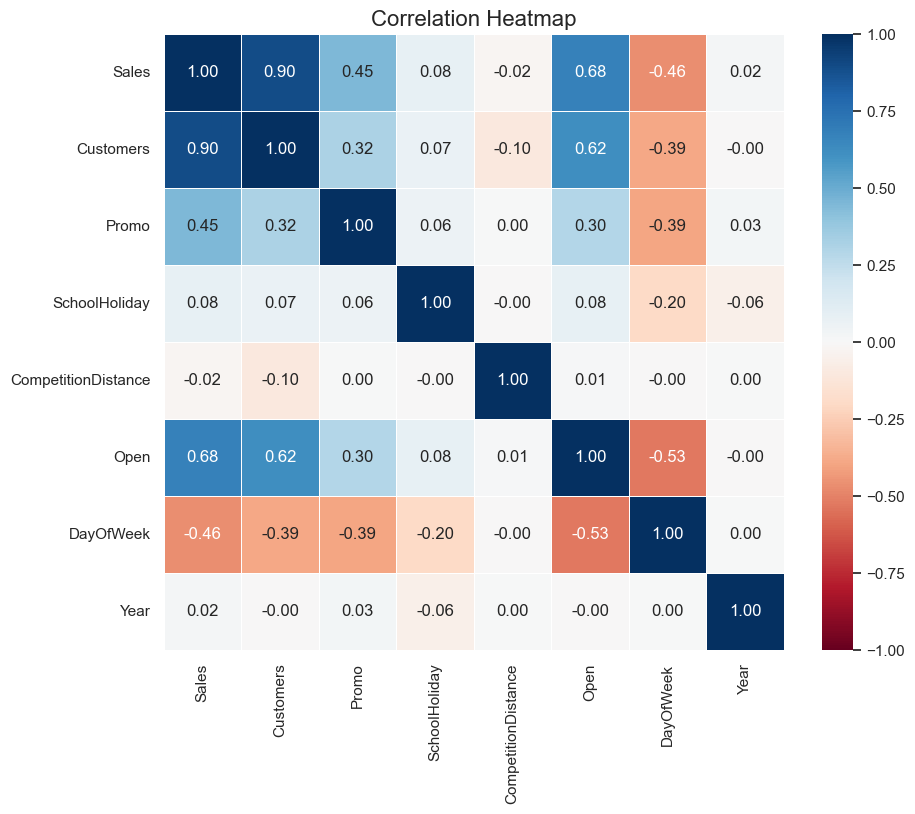

In [10]:
# ==========================================
# 4. Correlation Heatmap
# ==========================================
print("Generating correlation matrix...")

# Select numerical features for correlation
cols_for_corr = ['Sales', 'Customers', 'Promo', 'SchoolHoliday', 
                 'CompetitionDistance', 'Open', 'DayOfWeek', 'Year']

corr_matrix = df[cols_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

Comparing store types...


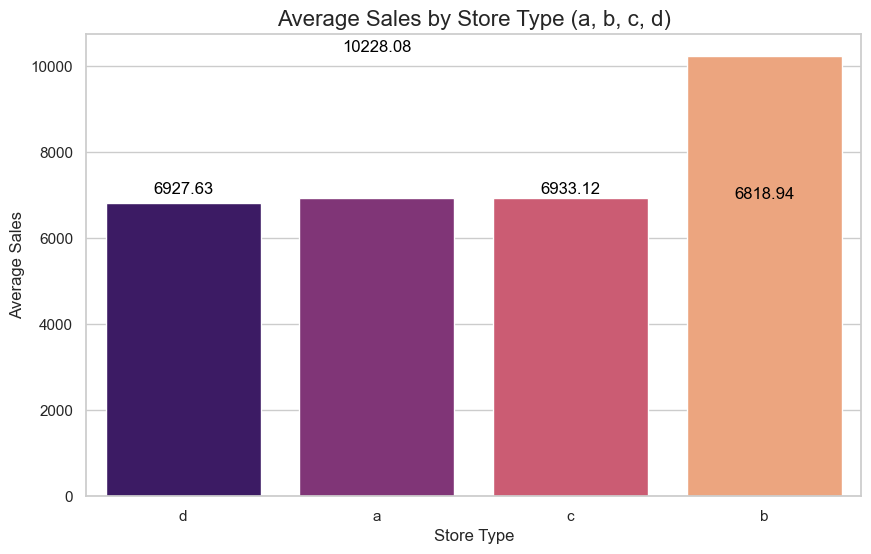

Analysis Complete.


In [11]:
# ==========================================
# 5. Store Type Comparison
# ==========================================
print("Comparing store types...")

# Aggregate sales by store type
store_type_sales = df_open.groupby('StoreType')['Sales'].mean().reset_index().sort_values('Sales')

plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(x='StoreType', y='Sales', data=store_type_sales, palette='magma')

# Add value labels on bars
for index, row in store_type_sales.iterrows():
    bar_plot.text(index, row.Sales + 100, round(row.Sales, 2), color='black', ha="center")

plt.title('Average Sales by Store Type (a, b, c, d)', fontsize=16)
plt.ylabel('Average Sales')
plt.xlabel('Store Type')
plt.show()

print("Analysis Complete.")
